# Chronic Kidney Disease (CKD) Diagnostic Pipeline
**Student Name:** `Youssef Hassanien`  
**Student ID:** `2220010`

In [252]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU, Input
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.regularizers import l2
from tensorflow.keras.metrics import Recall
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## Task 1: Data Pipeline
**Instructions:**
1. Load the `kidney_disease.csv` file.
2. Drop all categorical (string) columns to isolate the numerical lab values.
3. Handle missing values (`NaN`s).
4. Scale the features to prevent data leakage.
5. Perform an 80/20 train/validation split.

### 1- Load the `kidney_disease.csv` file

In [253]:
data = pd.read_csv('kidney_disease.csv')

data.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [254]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    str    
 7   pc              335 non-null    str    
 8   pcc             396 non-null    str    
 9   ba              396 non-null    str    
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    str    
 17  wc              295 non-null    str    
 18  r

In [255]:
data.isnull().sum()

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [256]:
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,400.0,NaN,NaN,NaN,199.5,115.614301,0.0,99.75,199.5,299.25,399.0
age,391.0,NaN,NaN,NaN,51.483376,17.169714,2.0,42.0,55.0,64.5,90.0
bp,388.0,NaN,NaN,NaN,76.469072,13.683637,50.0,70.0,80.0,80.0,180.0
sg,353.0,NaN,NaN,NaN,1.017408,0.005717,1.005,1.01,1.02,1.02,1.025
al,354.0,NaN,NaN,NaN,1.016949,1.352679,0.0,0.0,0.0,2.0,5.0
su,351.0,NaN,NaN,NaN,0.450142,1.099191,0.0,0.0,0.0,0.0,5.0
rbc,248,2,normal,201,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pc,335,2,normal,259,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pcc,396,2,notpresent,354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ba,396,2,notpresent,374,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2- Drop all categorical (string) columns to isolate the numerical lab values.

In [257]:
str_cols = data.select_dtypes(str).columns
str_dropped_data = data.drop(columns=str_cols)

str_dropped_data.head()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
0,0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,1.2,NaN,NaN,15.4
1,1,7.0,50.0,1.020,4.0,0.0,NaN,18.0,0.8,NaN,NaN,11.3
2,2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,1.8,NaN,NaN,9.6
3,3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,3.8,111.0,2.5,11.2
4,4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,1.4,NaN,NaN,11.6


In [258]:
str_dropped_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      400 non-null    int64  
 1   age     391 non-null    float64
 2   bp      388 non-null    float64
 3   sg      353 non-null    float64
 4   al      354 non-null    float64
 5   su      351 non-null    float64
 6   bgr     356 non-null    float64
 7   bu      381 non-null    float64
 8   sc      383 non-null    float64
 9   sod     313 non-null    float64
 10  pot     312 non-null    float64
 11  hemo    348 non-null    float64
dtypes: float64(11), int64(1)
memory usage: 37.6 KB


In [259]:
str_dropped_data.isnull().sum()

id       0
age      9
bp      12
sg      47
al      46
su      49
bgr     44
bu      19
sc      17
sod     87
pot     88
hemo    52
dtype: int64

In [260]:
# Check class distribution
print("\nTarget Variable Distribution:")
print(data['classification'].value_counts())

# Calculate percentage of CKD patients (including 'ckd' and 'ckd\t')
total_ckd = ((data['classification'] == 'ckd') | (data['classification'] == 'ckd\t')).sum()
total_patients = len(data)
percentage_ckd = (total_ckd / total_patients) * 100
print(f"\nPercentage of CKD patients: {percentage_ckd:.2f}%")


Target Variable Distribution:
classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64

Percentage of CKD patients: 62.50%


**Features correlation to the classification**

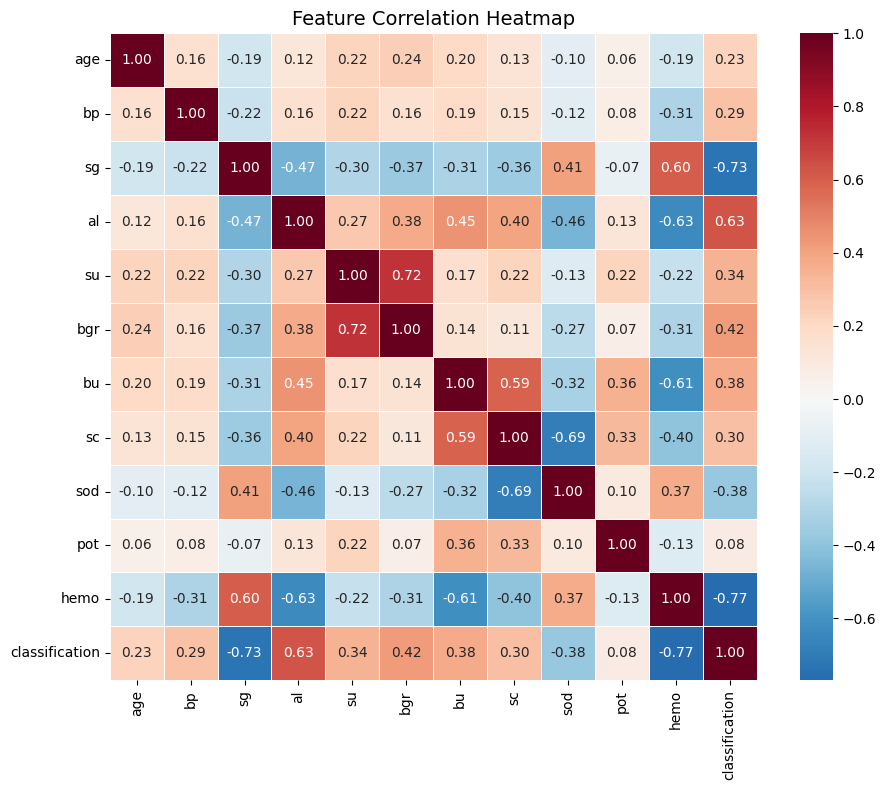

Correlation with Outcome (Diabetes):
classification    1.000000
al                0.627090
bgr               0.419672
bu                0.380605
su                0.344070
sc                0.299969
bp                0.294077
age               0.227268
pot               0.084541
sod              -0.375674
sg               -0.732163
hemo             -0.768919
Name: classification, dtype: float64


In [261]:
str_dropped_data['classification'] = data['classification'].map({'ckd': 1, 'ckd\t': 1, 'notckd': 0})
str_dropped_data.drop(columns=['id'], inplace=True)

# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = str_dropped_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, 
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

# Display correlations with target
print("Correlation with Outcome (Diabetes):")
print(correlation_matrix['classification'].sort_values(ascending=False))

### 3- Handle missing values (`NaN`s).

In [262]:
str_dropped_data.head()

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,classification
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,1.2,NaN,NaN,15.4,1
1,7.0,50.0,1.020,4.0,0.0,NaN,18.0,0.8,NaN,NaN,11.3,1
2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,1.8,NaN,NaN,9.6,1
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,3.8,111.0,2.5,11.2,1
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,1.4,NaN,NaN,11.6,1


**Separate CKD and not CKD data**

In [263]:
ckd_df = str_dropped_data[(str_dropped_data['classification'] == 1)]
not_ckd_df = str_dropped_data[str_dropped_data['classification'] == 0]

print('CKD data first 5 rows:')
print(ckd_df.head())

print('\nNOT CKD data first 5 rows:')
print(not_ckd_df.head())

CKD data first 5 rows:
    age    bp     sg   al   su    bgr    bu   sc    sod  pot  hemo  \
0  48.0  80.0  1.020  1.0  0.0  121.0  36.0  1.2    NaN  NaN  15.4   
1   7.0  50.0  1.020  4.0  0.0    NaN  18.0  0.8    NaN  NaN  11.3   
2  62.0  80.0  1.010  2.0  3.0  423.0  53.0  1.8    NaN  NaN   9.6   
3  48.0  70.0  1.005  4.0  0.0  117.0  56.0  3.8  111.0  2.5  11.2   
4  51.0  80.0  1.010  2.0  0.0  106.0  26.0  1.4    NaN  NaN  11.6   

   classification  
0               1  
1               1  
2               1  
3               1  
4               1  

NOT CKD data first 5 rows:
      age    bp     sg   al   su    bgr    bu   sc    sod  pot  hemo  \
250  40.0  80.0  1.025  0.0  0.0  140.0  10.0  1.2  135.0  5.0  15.0   
251  23.0  80.0  1.025  0.0  0.0   70.0  36.0  1.0  150.0  4.6  17.0   
252  45.0  80.0  1.025  0.0  0.0   82.0  49.0  0.6  147.0  4.4  15.9   
253  57.0  80.0  1.025  0.0  0.0  119.0  17.0  1.2  135.0  4.7  15.4   
254  51.0  60.0  1.025  0.0  0.0   99.0  38.0  0

**Null value percentage in each dataset**

In [264]:
null_percentage = (ckd_df.isnull().sum() / len(ckd_df)) * 100
print(f'CKD null percentage: {null_percentage}\n')
null_percentage = (not_ckd_df.isnull().sum() / len(not_ckd_df)) * 100
print(f'NOT CKD null percentage: {null_percentage}\n')

CKD null percentage: age                3.2
bp                 4.0
sg                16.8
al                16.4
su                17.6
bgr               15.2
bu                 5.2
sc                 4.8
sod               32.8
pot               33.2
hemo              18.4
classification     0.0
dtype: float64

NOT CKD null percentage: age               0.666667
bp                1.333333
sg                3.333333
al                3.333333
su                3.333333
bgr               4.000000
bu                4.000000
sc                3.333333
sod               3.333333
pot               3.333333
hemo              4.000000
classification    0.000000
dtype: float64



**Dropping all the null values in not ckd data as they are all less than 5% and replace all the null values in the ckd data with the mean if their percentage is bigger than 5% otherwise drop them**

In [265]:
# Create cleaned versions of the DataFrames
cleaned_not_ckd_df = not_ckd_df.dropna()

# Impute columns with >5% nulls with column mean for CKD data
columns_to_impute = ['sg', 'al', 'su', 'bgr', 'sod', 'pot', 'hemo']
cleaned_ckd_df = ckd_df.copy()
for col in columns_to_impute:
    cleaned_ckd_df[col] = cleaned_ckd_df[col].fillna(cleaned_ckd_df[col].mean())

# Drop any remaining rows with NaNs
cleaned_ckd_df = cleaned_ckd_df.dropna()

print("Cleaned CKD data shape:", cleaned_ckd_df.shape)
print("Cleaned NOT CKD data shape:", cleaned_not_ckd_df.shape)

print("\nCleaned CKD data info:\n")
print(cleaned_ckd_df.info())

print("\nCleaned NOT CKD data info:\n")
print(cleaned_not_ckd_df.info())

Cleaned CKD data shape: (220, 12)
Cleaned NOT CKD data shape: (127, 12)

Cleaned CKD data info:

<class 'pandas.DataFrame'>
Index: 220 entries, 0 to 249
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             220 non-null    float64
 1   bp              220 non-null    float64
 2   sg              220 non-null    float64
 3   al              220 non-null    float64
 4   su              220 non-null    float64
 5   bgr             220 non-null    float64
 6   bu              220 non-null    float64
 7   sc              220 non-null    float64
 8   sod             220 non-null    float64
 9   pot             220 non-null    float64
 10  hemo            220 non-null    float64
 11  classification  220 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 22.3 KB
None

Cleaned NOT CKD data info:

<class 'pandas.DataFrame'>
Index: 127 entries, 250 to 399
Data columns (total 12 columns):
 #   Co

In [266]:
cleaned_ckd_df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
age,220.0,56.354545,15.563736,5.000,48.000,60.000000,67.000000,90.000
bp,220.0,79.727273,15.583570,50.000,70.000,80.000000,90.000000,180.000
sg,220.0,1.013972,0.004267,1.005,1.010,1.013918,1.015000,1.025
al,220.0,1.763680,1.254191,0.000,1.000,1.722488,3.000000,5.000
su,220.0,0.799603,1.253821,0.000,0.000,0.000000,1.000000,5.000
bgr,220.0,175.772341,85.776293,22.000,111.750,161.000000,213.250000,490.000
bu,220.0,73.319091,59.152563,1.500,32.000,53.000000,93.250000,391.000
sc,220.0,4.436591,7.108419,0.600,1.500,2.250000,4.400000,76.000
sod,220.0,133.695982,10.765568,4.500,133.000,133.901786,137.250000,163.000
pot,220.0,4.921260,3.753404,2.500,4.100,4.878443,4.878443,47.000


In [267]:
cleaned_not_ckd_df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
age,127.0,46.929134,15.390773,12.00,35.00,47.000,58.000,80.000
bp,127.0,71.417323,8.611953,60.00,60.00,70.000,80.000,80.000
sg,127.0,1.022520,0.002510,1.02,1.02,1.025,1.025,1.025
al,127.0,0.000000,0.000000,0.00,0.00,0.000,0.000,0.000
su,127.0,0.000000,0.000000,0.00,0.00,0.000,0.000,0.000
bgr,127.0,107.338583,19.005104,70.00,93.00,108.000,123.500,140.000
bu,127.0,32.976378,11.664942,10.00,23.00,33.000,44.000,50.000
sc,127.0,0.871654,0.258167,0.40,0.60,0.900,1.100,1.200
sod,127.0,141.755906,4.708514,135.00,138.00,141.000,146.000,150.000
pot,127.0,4.325984,0.596978,3.30,3.70,4.500,4.900,5.000


**Merging back all the data together**

In [268]:
# Merge cleaned CKD and NOT CKD data back into one DataFrame
cleaned_data = pd.concat([cleaned_ckd_df, cleaned_not_ckd_df], ignore_index=True)

print("Merged cleaned data shape:", cleaned_data.shape)
print("Merged data info:")
print(cleaned_data.info())

Merged cleaned data shape: (347, 12)
Merged data info:
<class 'pandas.DataFrame'>
RangeIndex: 347 entries, 0 to 346
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             347 non-null    float64
 1   bp              347 non-null    float64
 2   sg              347 non-null    float64
 3   al              347 non-null    float64
 4   su              347 non-null    float64
 5   bgr             347 non-null    float64
 6   bu              347 non-null    float64
 7   sc              347 non-null    float64
 8   sod             347 non-null    float64
 9   pot             347 non-null    float64
 10  hemo            347 non-null    float64
 11  classification  347 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 32.7 KB
None


In [269]:
cleaned_data.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
age,347.0,52.904899,16.132388,5.000,44.000000,55.000,65.000000,90.000
bp,347.0,76.685879,14.028126,50.000,70.000000,80.000,80.000000,180.000
sg,347.0,1.017101,0.005551,1.005,1.013918,1.015,1.020000,1.025
al,347.0,1.118183,1.311295,0.000,0.000000,1.000,2.000000,5.000
su,347.0,0.506953,1.069497,0.000,0.000000,0.000,0.766990,5.000
bgr,347.0,150.725980,76.670273,22.000,100.000000,125.000,175.419811,490.000
bu,347.0,58.553890,51.410132,1.500,27.000000,44.000,66.500000,391.000
sc,347.0,3.131844,5.913070,0.400,0.950000,1.400,2.800000,76.000
sod,347.0,136.645868,9.825892,4.500,133.901786,136.000,141.000000,163.000
pot,347.0,4.703393,3.021463,2.500,3.900000,4.700,4.878443,47.000


**Cleaned data visualization**

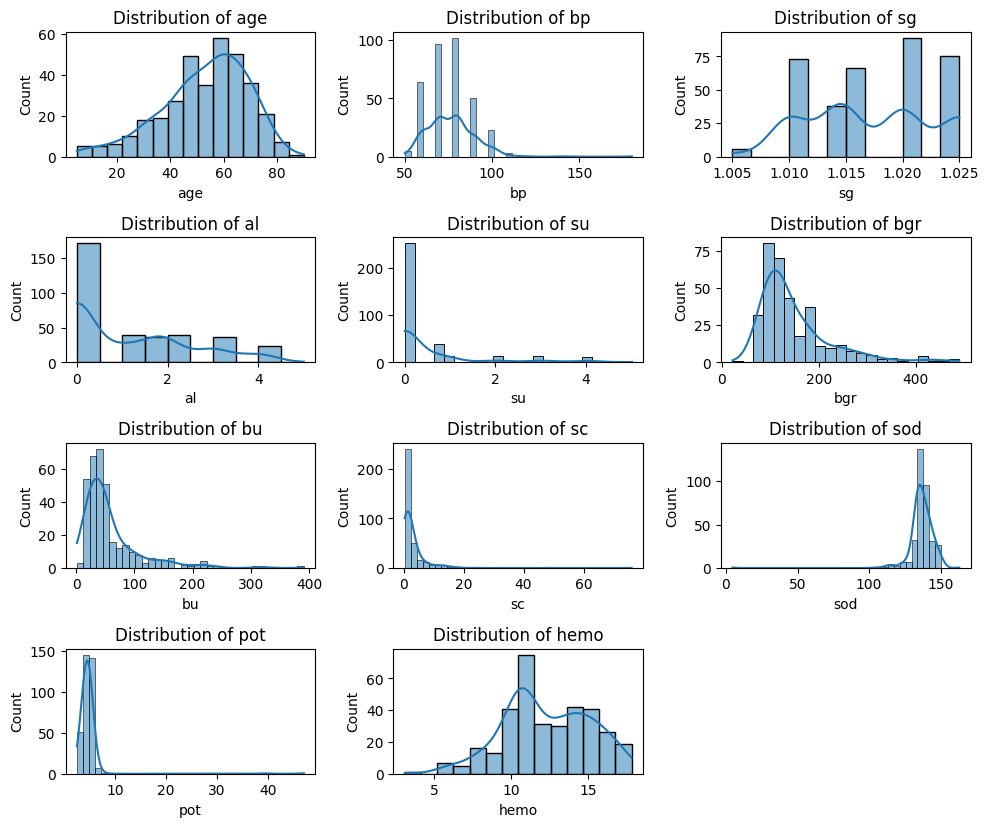

In [270]:
x_data = cleaned_data.iloc[:,:-1]
y_label = cleaned_data['classification']

numeric_cols = x_data.select_dtypes(include='number').columns

plt.figure(figsize=(10, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(5, 3, i)
    sns.histplot(x=x_data[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

### 4- Scale the features to prevent data leakage

### 5- Perform an 80/20 train/validation split.

In [271]:
scaler = StandardScaler()

X_train, X_val, y_train, y_val = train_test_split(
    x_data,
    y_label,
    train_size=0.8,
    random_state=42,
    stratify=y_label,           
)

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

## Task 2: The Engineered Failure (Baseline Model)
**Instructions:** Build and train an unregularised Dense network. Plot the training and validation loss curves to visually prove it overfits.

In [272]:
model_A = Sequential(
    [
        Input(shape=(11,)),         
        Dense(32, activation="relu"),
        Dense(16, activation="relu"),
        Dense(8, activation="relu"),
        Dense(1, activation="sigmoid"),
    ],
    name="Model_A_Baseline",
)

model_A.compile(
    optimizer=SGD(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy", Recall(name="recall")],
)

model_A.summary()

Model: "Model_A_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_107 (Dense)               │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_108 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_109 (Dense)               │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_110 (Dense)               │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,057 (4.13 KB)

 Trainable params: 1,057 (4.13 KB)

 Non-trainable params: 0 (0.00 B)

## Train Model A

In [273]:
print("Starting training of Model A...")
history_A = model_A.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150,                              
    batch_size=10,                                              
    callbacks=None,                     
    verbose=1                               
)

print("\n✓ Model A training is complete!")

Starting training of Model A...
Epoch 1/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6101 - loss: 0.6783 - recall: 0.3864 - val_accuracy: 0.7571 - val_loss: 0.6094 - val_recall: 0.6136
Epoch 2/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8303 - loss: 0.5738 - recall: 0.7500 - val_accuracy: 0.9286 - val_loss: 0.5016 - val_recall: 0.8864
Epoch 3/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9206 - loss: 0.4889 - recall: 0.8977 - val_accuracy: 0.9714 - val_loss: 0.4137 - val_recall: 0.9545
Epoch 4/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9495 - loss: 0.4120 - recall: 0.9432 - val_accuracy: 0.9714 - val_loss: 0.3354 - val_recall: 0.9545
Epoch 5/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9603 - loss: 0.3421 - recall: 0.9432 - val_accuracy: 0.9714 - val_loss: 0.2683 - val_recall: 0.9545
Epoch 6/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9747 - loss: 0.2815 - recall: 0.9602 - val_accuracy: 0.9714 - val_loss: 0.2146

## Task 3: The Clinical Solution (Engineered Model)
**Instructions:** Build a second model using regularisation techniques (e.g., L2, Dropout, LeakyReLU). Train it and plot the curves to demonstrate the reduction in overfitting.

### Early stop, Reduce learning rate on plateau callbacks, and Weights initialization  

In [274]:
# Feature weights based on absolute Pearson correlation with CKD classification
# Columns are in dataset order: age, bp, sg, al, su, bgr, bu, sc, sod, pot, hemo
feature_weights = np.array([
    0.3,   # age  | corr =  0.227268
    0.4,   # bp   | corr =  0.294077
    2.0,   # sg   | corr = -0.732163  (strong signal)
    1.5,   # al   | corr =  0.627090
    0.5,   # su   | corr =  0.344070
    0.6,   # bgr  | corr =  0.419672
    0.5,   # bu   | corr =  0.380605
    0.4,   # sc   | corr =  0.299969
    0.5,   # sod  | corr = -0.375674  (strong signal)
    0.1,   # pot  | corr =  0.084541
    2.0,   # hemo | corr = -0.768919  (strongest signal)
])

# Apply weights to scaled features
X_train_scaled = X_train_scaled * feature_weights
X_val_scaled = X_val_scaled * feature_weights

# Define callbacks for training
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

callbacks = [early_stopping, reduce_lr]

print("Callbacks configured:")
print("- EarlyStopping: Stops training if validation loss doesn't improve for 20 epochs")
print("- ReduceLROnPlateau: Reduces learning rate by 50% if validation loss plateaus for 10 epochs")

Callbacks configured:
- EarlyStopping: Stops training if validation loss doesn't improve for 20 epochs
- ReduceLROnPlateau: Reduces learning rate by 50% if validation loss plateaus for 10 epochs


## Build Model B

In [275]:
model_B = tf.keras.Sequential(
    [
        Input(shape=(11,)),          
        Dense(32, kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        LeakyReLU(alpha=0.01),
        Dropout(0.3),
        Dense(16, kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        LeakyReLU(alpha=0.01),
        Dropout(0.3),
        Dense(8, kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        LeakyReLU(alpha=0.01),
        Dropout(0.3),
        Dense(1, activation="sigmoid"),
    ],
    name="Model_B_Regularised",
)

model_B.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", Recall(name="recall")],
)

model_B.summary()

d:\Education\Deep learning in Medicine\Deep-Learning-Tasks\Neural Networks\.venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "Model_B_Regularised"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_111 (Dense)               │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_27 (LeakyReLU)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_112 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_28 (LeakyReLU)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_113 (Dense)               │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_29 (LeakyReLU)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_114 (Dense)               │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,281 (5.00 KB)

 Trainable params: 1,169 (4.57 KB)

 Non-trainable params: 112 (448.00 B)

## Train Model B

In [276]:
print("Starting training of Model B...")
history_B = model_B.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150,                              
    batch_size=10,                                              
    callbacks=callbacks,                     
    verbose=1                               
)

print("\n✓ Model B training is complete!")

Starting training of Model B...
Epoch 1/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5704 - loss: 0.7460 - recall: 0.6932 - val_accuracy: 0.9429 - val_loss: 0.4843 - val_recall: 0.9773 - learning_rate: 0.0010
Epoch 2/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6245 - loss: 0.6967 - recall: 0.7273 - val_accuracy: 0.9857 - val_loss: 0.4268 - val_recall: 0.9773 - learning_rate: 0.0010
Epoch 3/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7329 - loss: 0.5635 - recall: 0.7727 - val_accuracy: 0.9714 - val_loss: 0.3998 - val_recall: 0.9545 - learning_rate: 0.0010
Epoch 4/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7581 - loss: 0.5117 - recall: 0.8068 - val_accuracy: 0.9714 - val_loss: 0.3848 - val_recall: 0.9545 - learning_rate: 0.0010
Epoch 5/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7870 - loss: 0.4961 - recall: 0.8182 - val_accuracy: 0.9714 - val_loss: 0.3670 - val_recall: 0.9545 - learning_rate: 0.0010
Epoch 6/150
28/28 ━━━━

## Task 4: Evaluation & Mathematical Justification
**Instructions:**
1. Render the confusion matrices for both models.
2. Print the final validation Recall for both models.
3. Answer the justification question below.

In [277]:
# ── Final metric summary ────────────────────────────────────────────────────
print("\n─── Final Validation Metrics ───────────────────")
for name, hist in [("Model A", history_A), ("Model B", history_B)]:
    loss   = hist.history["val_loss"][-1]
    acc    = hist.history["val_accuracy"][-1]
    recall = hist.history["val_recall"][-1]
    print(f"{name:10s}  loss={loss:.4f}  acc={acc:.4f}  recall={recall:.4f}")


─── Final Validation Metrics ───────────────────
Model A     loss=0.0839  acc=0.9857  recall=0.9773
Model B     loss=0.0811  acc=0.9857  recall=0.9773


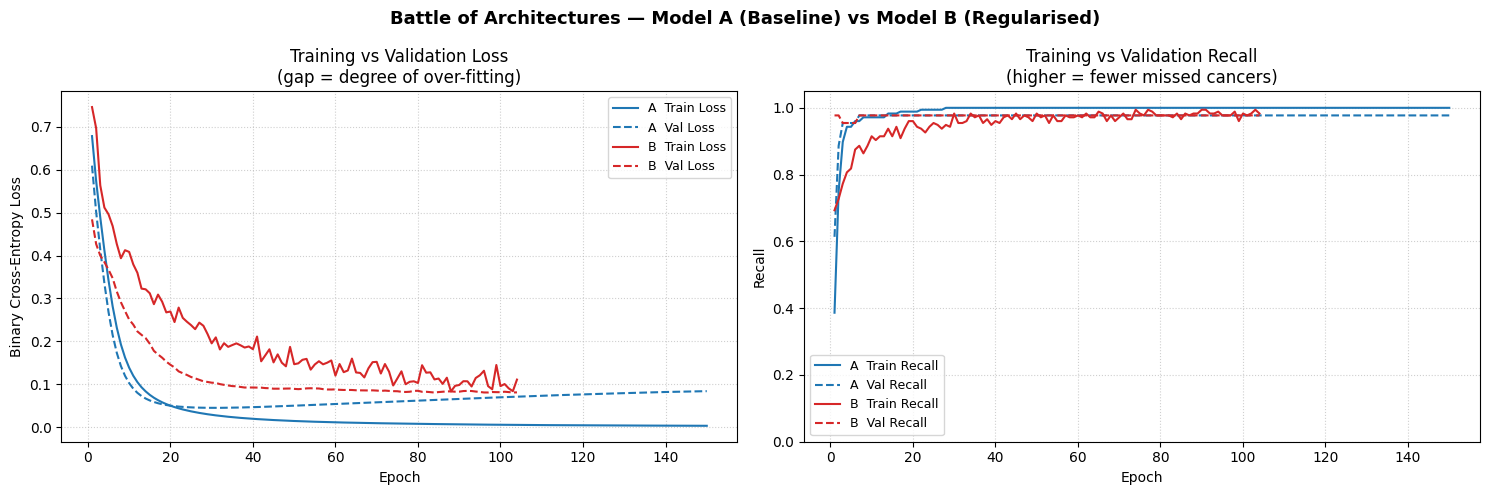

In [278]:
# Plotting both TRAINING and VALIDATION curves on same axis is essential:
# - A widening gap between the two lines is the visual signature of over-fitting.
# - Model B curves should converge more tightly than Model A.

epochs_A = range(1, len(history_A.history["val_loss"]) + 1)
epochs_B = range(1, len(history_B.history["val_loss"]) + 1)

COLOR_A_TRAIN = "#1f77b4"   # blue solid   — Model A train
COLOR_A_VAL   = "#1f77b4"   # blue dashed  — Model A val
COLOR_B_TRAIN = "#d62728"   # red solid    — Model B train
COLOR_B_VAL   = "#d62728"   # red dashed   — Model B val

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Battle of Architectures — Model A (Baseline) vs Model B (Regularised)",
             fontsize=13, fontweight="bold")

# ── Plot 1: Loss ─────────────────────────────────────────────────────────────
axes[0].plot(epochs_A, history_A.history["loss"],
             color=COLOR_A_TRAIN, linestyle="-",  label="A  Train Loss")
axes[0].plot(epochs_A, history_A.history["val_loss"],
             color=COLOR_A_VAL,   linestyle="--", label="A  Val Loss")
axes[0].plot(epochs_B, history_B.history["loss"],
             color=COLOR_B_TRAIN, linestyle="-",  label="B  Train Loss")
axes[0].plot(epochs_B, history_B.history["val_loss"],
             color=COLOR_B_VAL,   linestyle="--", label="B  Val Loss")
axes[0].set_title("Training vs Validation Loss\n(gap = degree of over-fitting)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].legend(fontsize=9)
axes[0].grid(True, linestyle=":", alpha=0.6)

# ── Plot 2: Recall ───────────────────────────────────────────────────────────
axes[1].plot(epochs_A, history_A.history["recall"],
             color=COLOR_A_TRAIN, linestyle="-",  label="A  Train Recall")
axes[1].plot(epochs_A, history_A.history["val_recall"],
             color=COLOR_A_VAL,   linestyle="--", label="A  Val Recall")
axes[1].plot(epochs_B, history_B.history["recall"],
             color=COLOR_B_TRAIN, linestyle="-",  label="B  Train Recall")
axes[1].plot(epochs_B, history_B.history["val_recall"],
             color=COLOR_B_VAL,   linestyle="--", label="B  Val Recall")
axes[1].set_title("Training vs Validation Recall\n(higher = fewer missed cancers)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Recall")
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=9)
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

═══════════════════════════════════════════════════════
  Model A (Baseline — SGD, no regularisation)
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

     NOT CKD       0.93      1.00      0.96        26
         CKD       1.00      0.95      0.98        44

    accuracy                           0.97        70
   macro avg       0.96      0.98      0.97        70
weighted avg       0.97      0.97      0.97        70

═══════════════════════════════════════════════════════
  Model B (Regularised — Adam + L2 + Dropout)
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

     NOT CKD       0.96      1.00      0.98        26
         CKD       1.00      0.98      0.99        44

    accuracy                           0.99        70
   macro avg       0.98      0.99      0.98        70
weighted avg       0.99      0.99      0.99        70



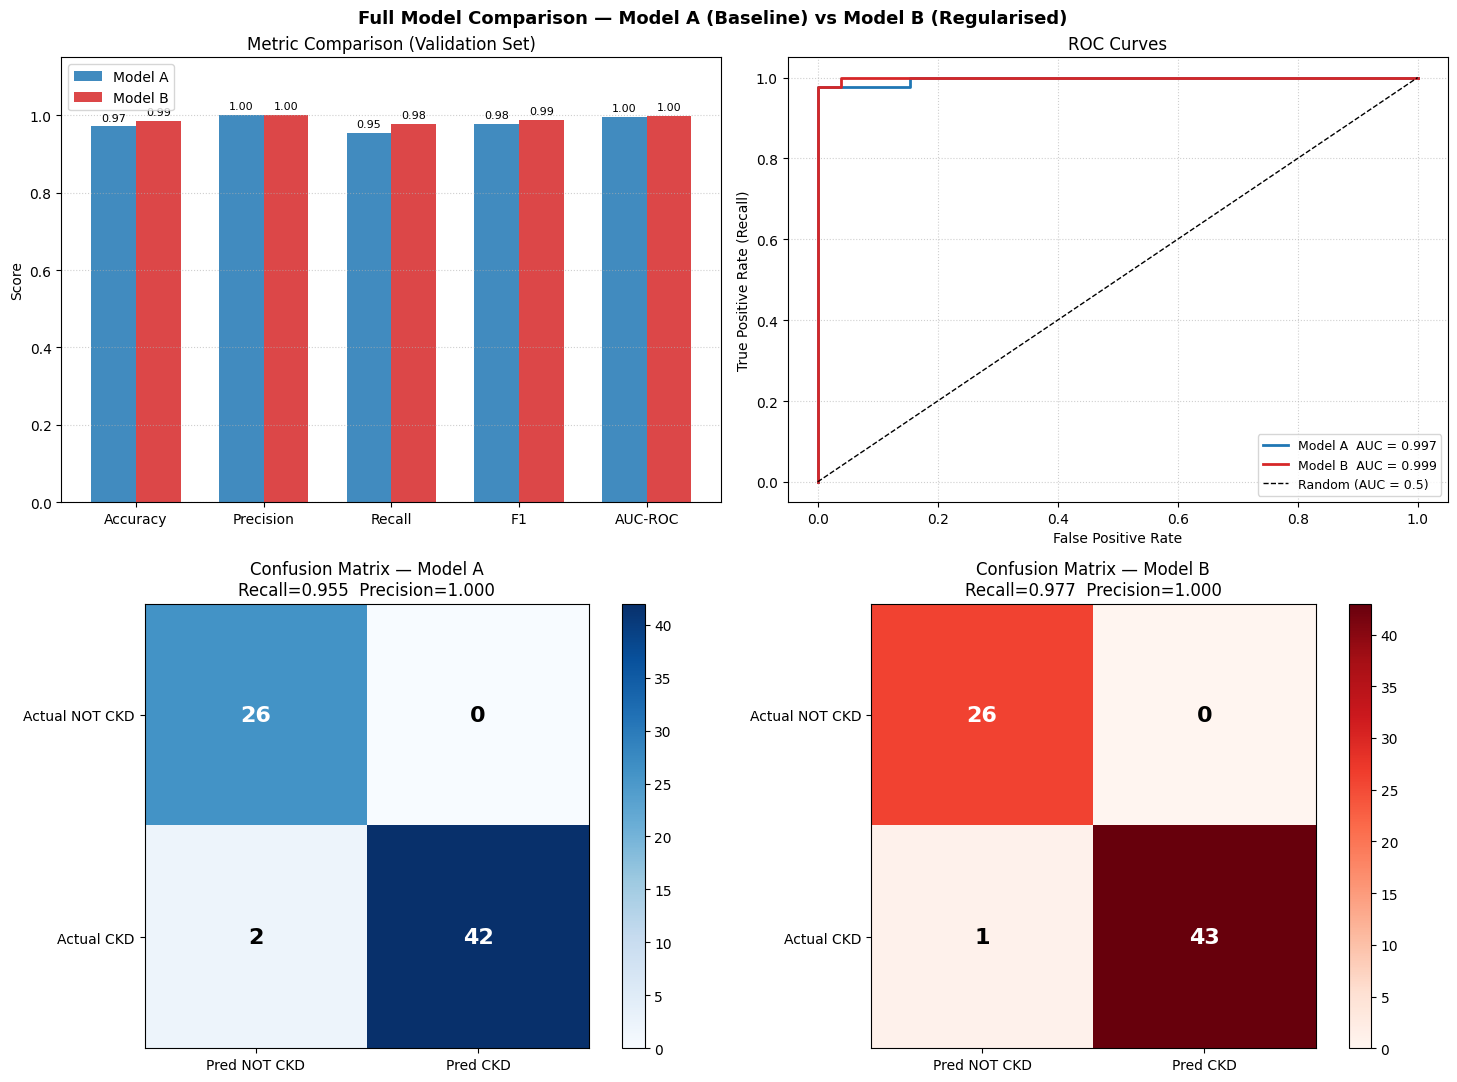


─── Δ Model B − Model A (validation set) ───────────
  Accuracy    : 0.9714  →  0.9857   ▲ 0.0143
  Precision   : 1.0000  →  1.0000   ─ 0.0000
  Recall      : 0.9545  →  0.9773   ▲ 0.0227
  F1          : 0.9767  →  0.9885   ▲ 0.0118
  AUC-ROC     : 0.9965  →  0.9991   ▲ 0.0026


In [279]:
# ── Hard predictions (threshold = 0.5) ───────────────────────────────────────
y_pred_A_prob = model_A.predict(X_val_scaled, verbose=0).ravel()
y_pred_B_prob = model_B.predict(X_val_scaled, verbose=0).ravel()

y_pred_A = (y_pred_A_prob >= 0.5).astype(int)
y_pred_B = (y_pred_B_prob >= 0.5).astype(int)

# ── Scalar metrics ────────────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return {
        "Accuracy" : accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall"   : recall_score(y_true, y_pred, zero_division=0),
        "F1"       : f1_score(y_true, y_pred, zero_division=0),
        "AUC-ROC"  : auc(fpr, tpr),
        "fpr"      : fpr,
        "tpr"      : tpr,
    }

metrics_A = compute_metrics(y_val, y_pred_A, y_pred_A_prob)
metrics_B = compute_metrics(y_val, y_pred_B, y_pred_B_prob)

# ── Printed classification reports ───────────────────────────────────────────
print("═" * 55)
print("  Model A (Baseline — SGD, no regularisation)")
print("═" * 55)
print(classification_report(y_val, y_pred_A,
                             target_names=["NOT CKD", "CKD"]))

print("═" * 55)
print("  Model B (Regularised — Adam + L2 + Dropout)")
print("═" * 55)
print(classification_report(y_val, y_pred_B,
                             target_names=["NOT CKD", "CKD"]))

# ── Figure layout: 2 rows × 2 cols ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle("Full Model Comparison — Model A (Baseline) vs Model B (Regularised)",
             fontsize=13, fontweight="bold")

BLUE, RED = "#1f77b4", "#d62728"
metric_keys = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]

# ── Plot 1 (top-left): Side-by-side bar chart of all scalar metrics ───────────
x       = np.arange(len(metric_keys))
bar_w   = 0.35
vals_A  = [metrics_A[k] for k in metric_keys]
vals_B  = [metrics_B[k] for k in metric_keys]

bars_A = axes[0, 0].bar(x - bar_w / 2, vals_A, bar_w, label="Model A", color=BLUE, alpha=0.85)
bars_B = axes[0, 0].bar(x + bar_w / 2, vals_B, bar_w, label="Model B", color=RED,  alpha=0.85)

# Annotate bar heights
for bar in bars_A:
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01, f"{bar.get_height():.2f}",
                    ha="center", va="bottom", fontsize=8)
for bar in bars_B:
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01, f"{bar.get_height():.2f}",
                    ha="center", va="bottom", fontsize=8)

axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metric_keys)
axes[0, 0].set_ylim(0, 1.15)
axes[0, 0].set_ylabel("Score")
axes[0, 0].set_title("Metric Comparison (Validation Set)")
axes[0, 0].legend()
axes[0, 0].grid(axis="y", linestyle=":", alpha=0.6)

# ── Plot 2 (top-right): ROC curves ───────────────────────────────────────────
axes[0, 1].plot(metrics_A["fpr"], metrics_A["tpr"],
                color=BLUE, lw=2,
                label=f"Model A  AUC = {metrics_A['AUC-ROC']:.3f}")
axes[0, 1].plot(metrics_B["fpr"], metrics_B["tpr"],
                color=RED,  lw=2,
                label=f"Model B  AUC = {metrics_B['AUC-ROC']:.3f}")
axes[0, 1].plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC = 0.5)")
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate (Recall)")
axes[0, 1].set_title("ROC Curves")
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, linestyle=":", alpha=0.6)

# ── Plot 3 (bottom-left): Confusion matrix — Model A ─────────────────────────
cm_A = confusion_matrix(y_val, y_pred_A)
im_A = axes[1, 0].imshow(cm_A, interpolation="nearest", cmap="Blues")
axes[1, 0].set_title(f"Confusion Matrix — Model A\n"
                     f"Recall={metrics_A['Recall']:.3f}  "
                     f"Precision={metrics_A['Precision']:.3f}")
for i in range(2):
    for j in range(2):
        axes[1, 0].text(j, i, str(cm_A[i, j]),
                        ha="center", va="center",
                        color="white" if cm_A[i, j] > cm_A.max() / 2 else "black",
                        fontsize=16, fontweight="bold")
axes[1, 0].set_xticks([0, 1]); axes[1, 0].set_xticklabels(["Pred NOT CKD", "Pred CKD"])
axes[1, 0].set_yticks([0, 1]); axes[1, 0].set_yticklabels(["Actual NOT CKD", "Actual CKD"])
plt.colorbar(im_A, ax=axes[1, 0])

# ── Plot 4 (bottom-right): Confusion matrix — Model B ────────────────────────
cm_B = confusion_matrix(y_val, y_pred_B)
im_B = axes[1, 1].imshow(cm_B, interpolation="nearest", cmap="Reds")
axes[1, 1].set_title(f"Confusion Matrix — Model B\n"
                     f"Recall={metrics_B['Recall']:.3f}  "
                     f"Precision={metrics_B['Precision']:.3f}")
for i in range(2):
    for j in range(2):
        axes[1, 1].text(j, i, str(cm_B[i, j]),
                        ha="center", va="center",
                        color="white" if cm_B[i, j] > cm_B.max() / 2 else "black",
                        fontsize=16, fontweight="bold")
axes[1, 1].set_xticks([0, 1]); axes[1, 1].set_xticklabels(["Pred NOT CKD", "Pred CKD"])
axes[1, 1].set_yticks([0, 1]); axes[1, 1].set_yticklabels(["Actual NOT CKD", "Actual CKD"])
plt.colorbar(im_B, ax=axes[1, 1])

plt.tight_layout()
plt.show()

# ── Delta summary ─────────────────────────────────────────────────────────────
print("\n─── Δ Model B − Model A (validation set) ───────────")
for k in metric_keys:
    delta = metrics_B[k] - metrics_A[k]
    direction = "▲" if delta > 0 else ("▼" if delta < 0 else "─")
    print(f"  {k:<12}: {metrics_A[k]:.4f}  →  {metrics_B[k]:.4f}   {direction} {abs(delta):.4f}")

### Mathematical Justification
**Final Parameter Count of Engineered Model:** `(11*32)+32+(4*32)+(32*16)+16+(4*16)+(16*8)+8+(4*8)+(8*1)+1=1281`

**Explanation:** `The drop out mechanism with the l2 regularization both help in making some of the neurons dead during the training which helps the model to generalize and not memorizing the noise in the data as some of the hidden layers that include dead neurons do not propagate the weights and errors of the overfitted parameters`